# Módulo Visualização de Dados:

Leia o arquivo ecommerce_preparados.csv’ dentro de um dataframe  

Faça uma análise detalhada dos dados, descubra quais dados gostaria de destacar e crie os seguintes gráficos:


*   1 Gráfico de dispersão
*   1 Mapa de calor
*   1 Gráfico de barra
*   1 Gráfico de pizza
*   1 Gráfico de densidade

Adicione títulos nos gráficos e nos eixos para ficar claro os objetivos dos gráficos.

Fiquem a vontade para escolher a biblioteca que quiserem, não esqueçam de comentar os códigos.

Essa atividade é um pouco diferente, vocês terão que construir os códigos nesse arquivo e enviar ou o arquivo ou o link do github com o arquivo publicado para os tutores.

In [74]:
%pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [75]:
# Importação das bibliotecas

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [76]:
# Carregamento da base preparada

df = pd.read_csv(
    r'C:\Users\lhog1\OneDrive\Documentos\ANALISTA DE DADOS\CURSOS\EBAC\Módulo 10\ecommerce_preparados.csv'
)

display(df.head())
print(df.shape)
print(df.dtypes)

,Unnamed: 0,Título,Nota,N_Avaliações,Desconto,Marca,Material,Gênero,Temporada,Review1,...,Nota_MinMax,N_Avaliações_MinMax,Desconto_MinMax,Preço_MinMax,Marca_Cod,Material_Cod,Temporada_Cod,Qtd_Vendidos_Cod,Marca_Freq,Material_Freq
0,0,Pijama Cirurgico Scrub Roupa Privativa Hospit...,4.0,273.0,NaN,toronto uniformes profissionais,poliéster,Sem gênero,não definido,"Preço justo , bem feito acabamento ok. Única s...",...,0.629630,0.029969,NaN,0.100645,781,122,1,1000.0,0.002274,0.117326
1,1,Kit 10 Cuecas Boxer Lupo Cueca Box Algodão Mas...,4.5,3034.0,18.0,lupo,algodão,Masculino,outono/inverno,As cuecas são boas; porém você percebe na cost...,...,0.814815,0.334178,0.213115,0.378585,463,25,3,10000.0,0.042292,0.176444
2,2,Kit Com 10 Cuecas Boxer Algodão Sem Costura Zo...,4.7,5682.0,20.0,zorba,algodão,Masculino,não definido,O tecido é bom e são confortáveis. Só que a nu...,...,0.888889,0.625937,0.245902,0.322329,838,25,1,50000.0,0.009095,0.176444
3,3,Kit 10 Cuecas Boxer Mash Algodão Cotton Box Or...,4.6,1700.0,22.0,mash,algodão,Masculino,primavera/verão,"As cuecas são boas, porém meu marido usa g e p...",...,0.851852,0.187197,0.278689,0.372617,494,25,7,10000.0,0.010914,0.176444
4,4,Kit 3 Short Jeans Feminino Cintura Alta Barato...,4.4,507.0,9.0,menina linda,jean,Feminino,primavera/verão,Estou encantada com essas peças!.\nOs shorts s...,...,0.777778,0.055751,0.065574,0.201767,509,74,7,1000.0,0.010005,0.025466


(2199, 24)
Unnamed: 0               int64
Título                     str
Nota                   float64
N_Avaliações           float64
Desconto               float64
Marca                      str
Material                   str
Gênero                     str
Temporada                  str
Review1                    str
Review2                    str
Review3                    str
Qtd_Vendidos               str
Preço                  float64
Nota_MinMax            float64
N_Avaliações_MinMax    float64
Desconto_MinMax        float64
Preço_MinMax           float64
Marca_Cod                int64
Material_Cod             int64
Temporada_Cod            int64
Qtd_Vendidos_Cod       float64
Marca_Freq             float64
Material_Freq          float64
dtype: object


In [77]:
# Verificação dos dados preparados

print(df.info())

print('\nValores ausentes por coluna:')
print(df.isnull().sum())

print('\nColunas disponíveis:')
print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 2199 entries, 0 to 2198
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           2199 non-null   int64  
 1   Título               2199 non-null   str    
 2   Nota                 1559 non-null   float64
 3   N_Avaliações         1559 non-null   float64
 4   Desconto             874 non-null    float64
 5   Marca                2199 non-null   str    
 6   Material             1332 non-null   str    
 7   Gênero               2120 non-null   str    
 8   Temporada            2199 non-null   str    
 9   Review1              1515 non-null   str    
 10  Review2              1354 non-null   str    
 11  Review3              1233 non-null   str    
 12  Qtd_Vendidos         2199 non-null   str    
 13  Preço                1964 non-null   float64
 14  Nota_MinMax          1559 non-null   float64
 15  N_Avaliações_MinMax  1559 non-null   float64
 16 

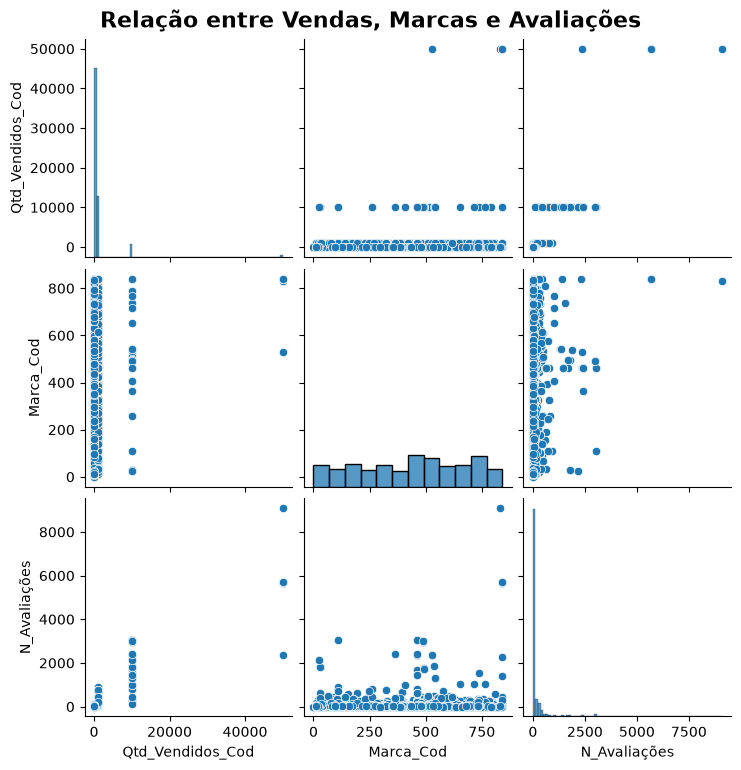

In [78]:
# Gráfico de Pairplot - Dispersão e Histograma

colunas_pairplot = [
    'Qtd_Vendidos_Cod',
    'Marca_Cod',
    'N_Avaliações'
]

grafico = sns.pairplot(
    df[colunas_pairplot].dropna(),
    diag_kind='hist'
)

grafico.fig.suptitle(
    'Relação entre Vendas, Marcas e Avaliações',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

grafico.savefig(
    'Imagem/pairplot_vendas_marcas_avaliacoes.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

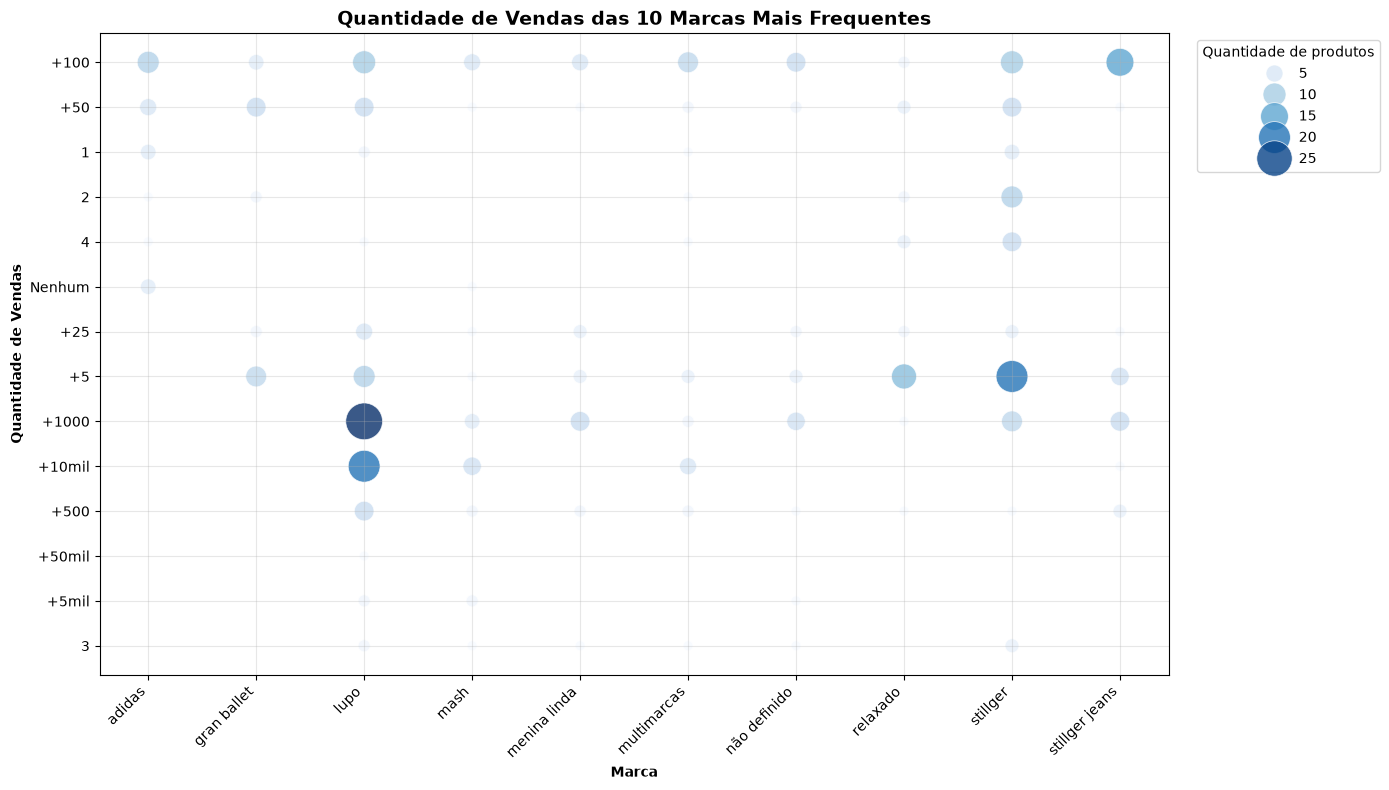

In [79]:
# Seleciona as 10 marcas mais frequentes
top_10_marcas = df['Marca'].value_counts().head(10).index

dados_top_10 = df[df['Marca'].isin(top_10_marcas)]

# Conta as ocorrências de cada combinação
contagem = (
    dados_top_10
    .groupby(['Marca', 'Qtd_Vendidos'])
    .size()
    .reset_index(name='Quantidade')
)

# Gráfico de dispersão com bolhas
plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=contagem,
    x='Marca',
    y='Qtd_Vendidos',
    size='Quantidade',
    hue='Quantidade',
    sizes=(50, 700),
    palette='Blues',
    alpha=0.8
)

plt.title(
    'Quantidade de Vendas das 10 Marcas Mais Frequentes',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Marca', fontweight='bold')
plt.ylabel('Quantidade de Vendas', fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)
plt.legend(
    title='Quantidade de produtos',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()

plt.savefig(
    'Imagem/top_10_marcas_quantidade_vendas.png',
    dpi=300,
    bbox_inches='tight'
)


plt.show()

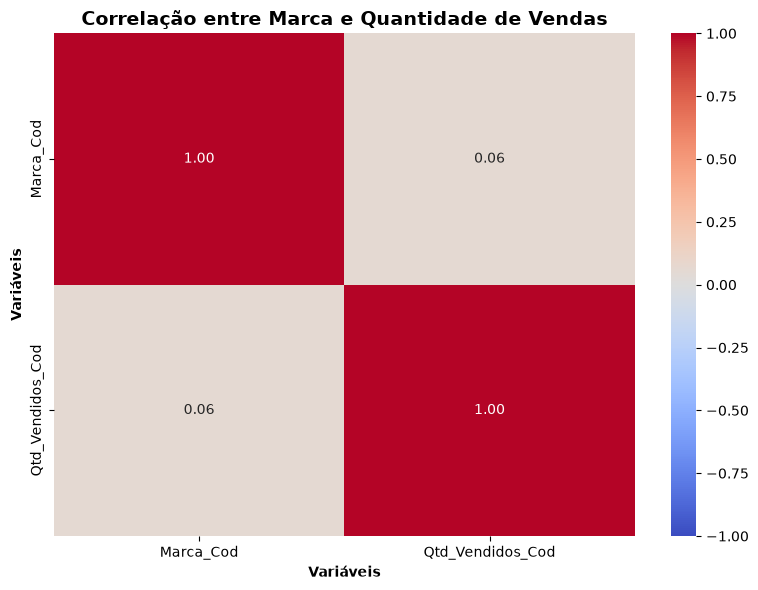

In [80]:
# Mapa de Calor — Correlação entre Marca e Quantidade de Vendas

corr = df[
    ['Marca_Cod', 'Qtd_Vendidos_Cod']
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.title(
    'Correlação entre Marca e Quantidade de Vendas',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Variáveis', fontweight='bold')
plt.ylabel('Variáveis', fontweight='bold')

plt.tight_layout()

plt.savefig(
    'Imagem/correlacao_marca_quantidade_vendas.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


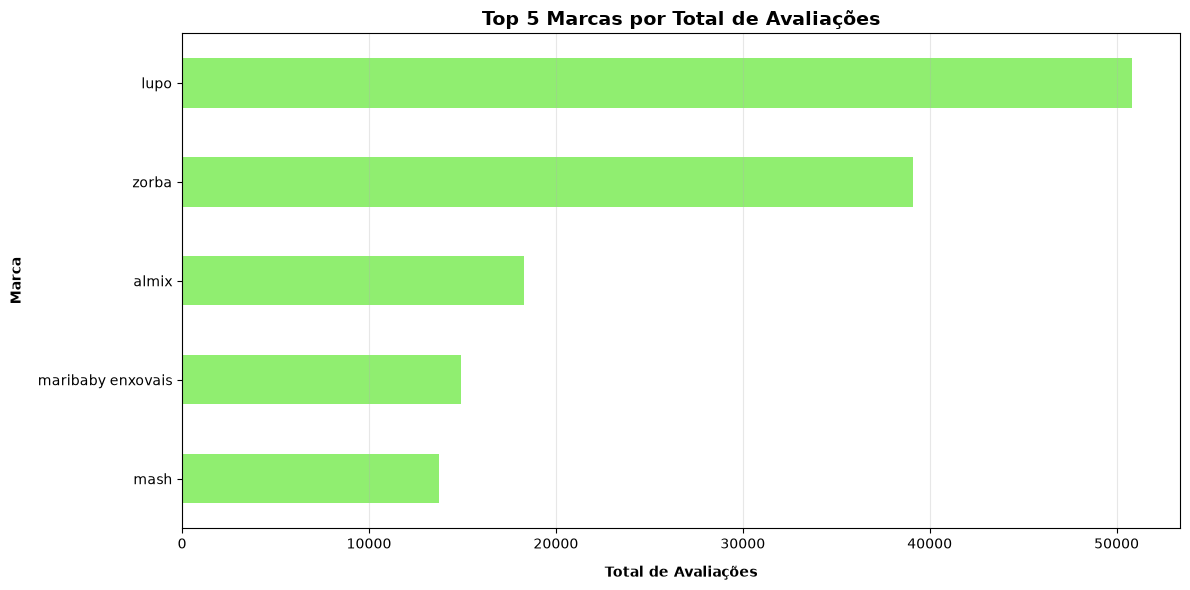

In [81]:
# Barras — Top 5 Marcas por Total de Avaliações

top_5_marcas = (
    df.groupby('Marca')['N_Avaliações']
    .sum()
    .nlargest(5)
    .sort_values()
)

plt.figure(figsize=(12, 6))

top_5_marcas.plot(
    kind='barh',
    color='#90ee70'
)

plt.title(
    'Top 5 Marcas por Total de Avaliações',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Total de Avaliações',
    fontsize=10,
    fontweight='bold',
    labelpad=10
)

plt.ylabel(
    'Marca',
    fontsize=10,
    fontweight='bold',
    labelpad=10
)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

plt.savefig(
    'Imagem/top_5_marcas_total_avaliacoes.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

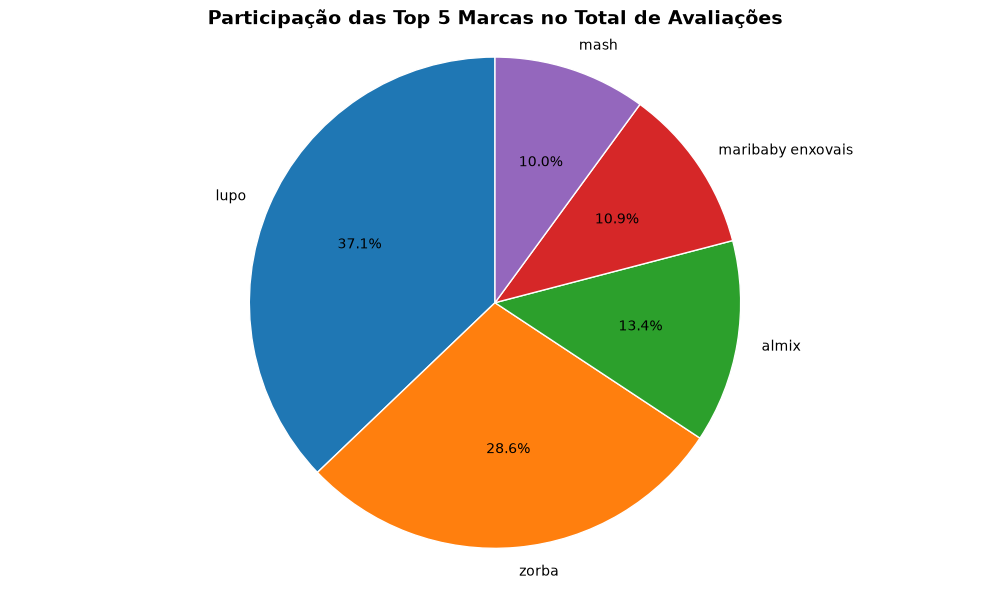

In [82]:
# Pizza — Participação das Top 5 Marcas nas Avaliações

top_5_marcas = (
    df.groupby('Marca')['N_Avaliações']
    .sum()
    .nlargest(5)
)

plt.figure(figsize=(10, 6))

plt.pie(
    top_5_marcas.values,
    labels=top_5_marcas.index,
    autopct='%.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'},
    textprops={'fontsize': 10}
)

plt.title(
    'Participação das Top 5 Marcas no Total de Avaliações',
    fontsize=14,
    fontweight='bold'
)

plt.axis('equal')
plt.tight_layout()

plt.savefig(
    'Imagem/participacao_top_5_marcas_avaliacoes.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

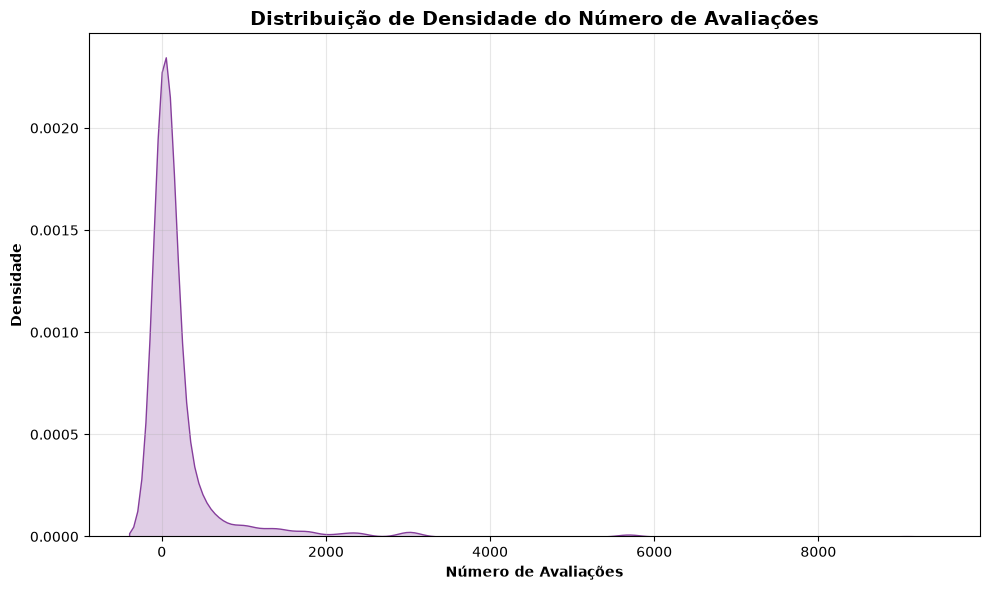

In [83]:
# Gráfico de Densidade — Número de Avaliações

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x='N_Avaliações',
    fill=True,
    color='#863e9c'
)

plt.title(
    'Distribuição de Densidade do Número de Avaliações',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Número de Avaliações', fontweight='bold')
plt.ylabel('Densidade', fontweight='bold')

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    'Imagem/densidade_numero_avaliacoes.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

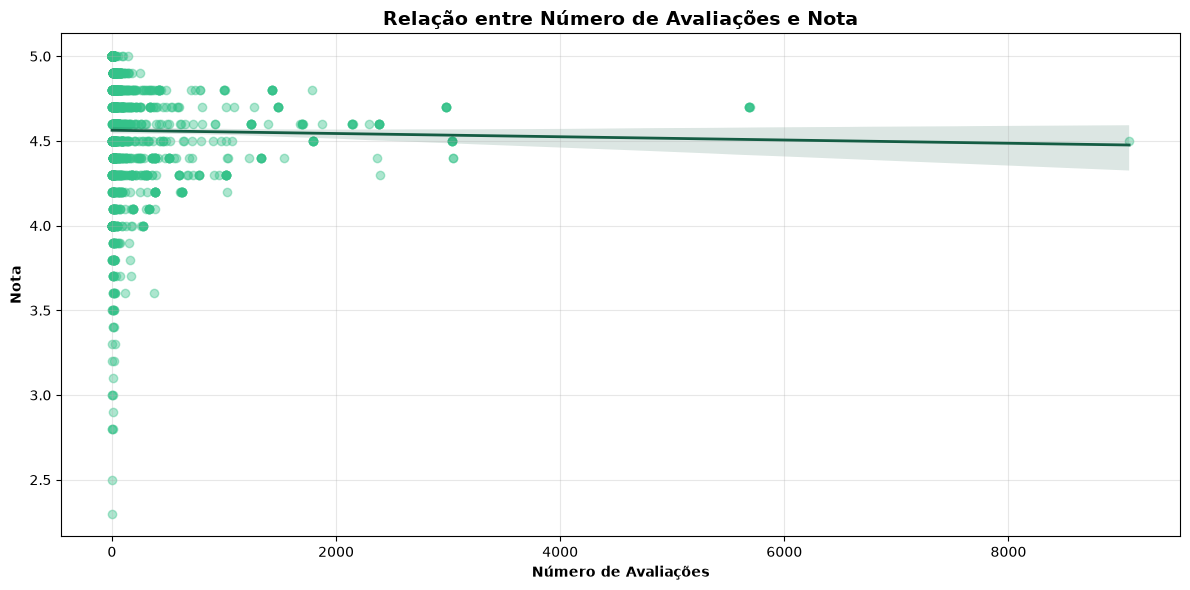

In [84]:
# Gráfico de Regressão entre Número de Avaliações e Nota


plt.figure(figsize=(12, 6))

sns.regplot(
    data=df,
    x='N_Avaliações',
    y='Nota',
    scatter_kws={
        'alpha': 0.4,
        'color': '#34c289'
    },
    line_kws={
        'color': '#145c43',
        'linewidth': 2
    }
)

plt.title(
    'Relação entre Número de Avaliações e Nota',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Número de Avaliações', fontweight='bold')
plt.ylabel('Nota', fontweight='bold')

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    'Imagem/regressao_avaliacoes_nota.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()